In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Data Pre-processing packages needed
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

This will be the Modelling Part and comparing which one is better

In [2]:
df = pd.read_csv("data_science_job_clean_v2.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (5000, 12)


,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2022,Machine Learning Engineer,Analysis,EUR,186597,136086,US,MI,CT,Remote,DE,L
1,2020,Statistician,ML/AI,JPY,110630,67982,JP,EX,FL,Remote,IN,M
2,2022,Machine Learning Engineer,ML/AI,INR,61280,153309,UK,MI,CT,Hybrid,CN,L
3,2022,Data Analyst,ML/AI,JPY,154130,135242,DE,SE,FT,Hybrid,MX,L
4,2020,Statistician,Data Science,EUR,172312,35156,UK,MI,FT,In-person,UK,S


Checking For basic info again

In [3]:
print("===== DATASET INFORMATION =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isna().sum())

print("\n===== DUPLICATES =====")
print("Duplicate rows:", df.duplicated().sum())

===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           5000 non-null   int64 
 1   job_title           5000 non-null   object
 2   job_category        4899 non-null   object
 3   salary_currency     5000 non-null   object
 4   salary              5000 non-null   int64 
 5   salary_in_usd       5000 non-null   int64 
 6   employee_residence  5000 non-null   object
 7   experience_level    5000 non-null   object
 8   employment_type     5000 non-null   object
 9   work_setting        5000 non-null   object
 10  company_location    5000 non-null   object
 11  company_size        4500 non-null   object
dtypes: int64(3), object(9)
memory usage: 468.9+ KB

===== MISSING VALUES =====
work_year               0
job_title               0
job_category          101
salary_currency         0
salar

# Exploratory Data Analysis

In [4]:
print("===== SALARY STATISTICS =====")

print(df["salary_in_usd"].describe())

===== SALARY STATISTICS =====
count      5000.000000
mean     114076.995800
std       49113.807687
min       30016.000000
25%       71343.750000
50%      114167.000000
75%      156665.750000
max      199985.000000
Name: salary_in_usd, dtype: float64


### Salary histogram

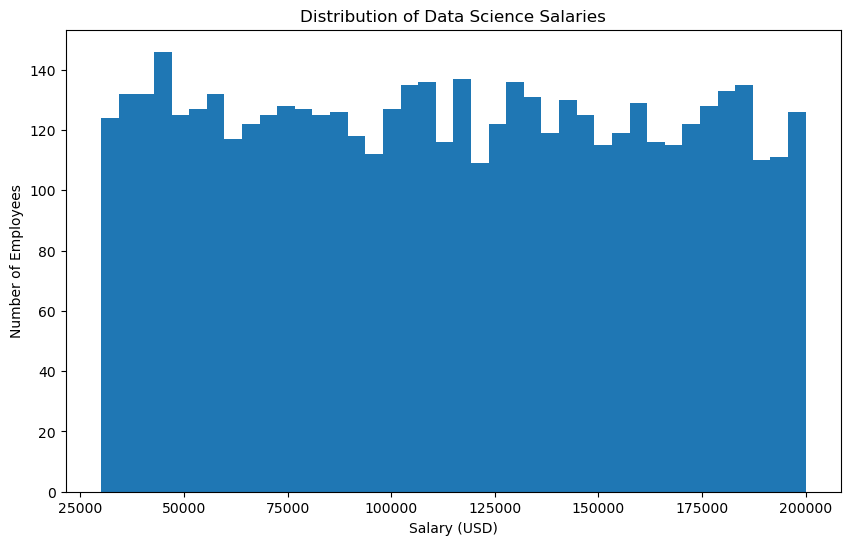

In [5]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["salary_in_usd"],
    bins=40
)

plt.xlabel("Salary (USD)")
plt.ylabel("Number of Employees")
plt.title("Distribution of Data Science Salaries")

plt.show()

This tells us whether salaries are:

    normally distributed
    heavily concentrated around certain values
    skewed toward high salaries
    containing potential outliers

# Salary by Job Title

In [6]:
salary_by_job = (
    df.groupby("job_title")["salary_in_usd"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

display(salary_by_job)

,count,mean,median,min,max
job_title,,,,,
Statistician,994,116039.247485,117382.0,30056,199790
Data Analyst,984,113921.636179,114794.5,30348,199894
Data Engineer,1065,113264.465728,114194.0,30178,199964
Machine Learning Engineer,964,113499.935685,112519.5,30209,199734
Data Scientist,993,113698.371601,111096.0,30016,199985


# Visuals cause why not

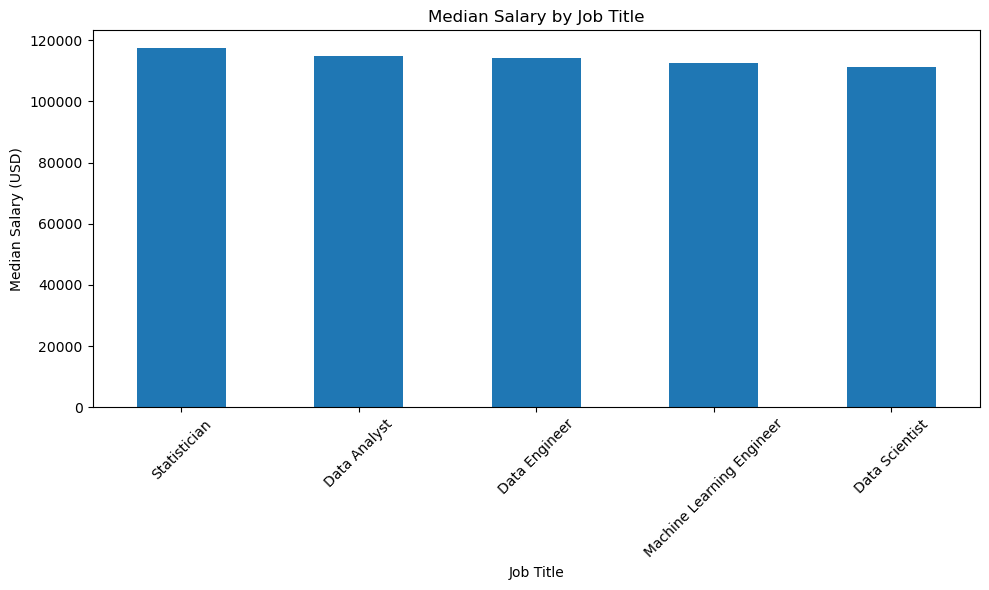

In [7]:
job_salary = (
    df.groupby("job_title")["salary_in_usd"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

job_salary.plot(kind="bar")

plt.xlabel("Job Title")
plt.ylabel("Median Salary (USD)")
plt.title("Median Salary by Job Title")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Salary by Experience Level

In [8]:
experience_salary = (
    df.groupby("experience_level")["salary_in_usd"]
    .agg(["count", "mean", "median", "min", "max"])
)

display(experience_salary)

,count,mean,median,min,max
experience_level,,,,,
EN,1234,115868.185575,116817.0,30056,199985
EX,1232,113493.545455,111820.5,30337,199734
MI,1238,114085.300485,114694.0,30290,199964
SE,1296,112918.200617,113485.0,30016,199894


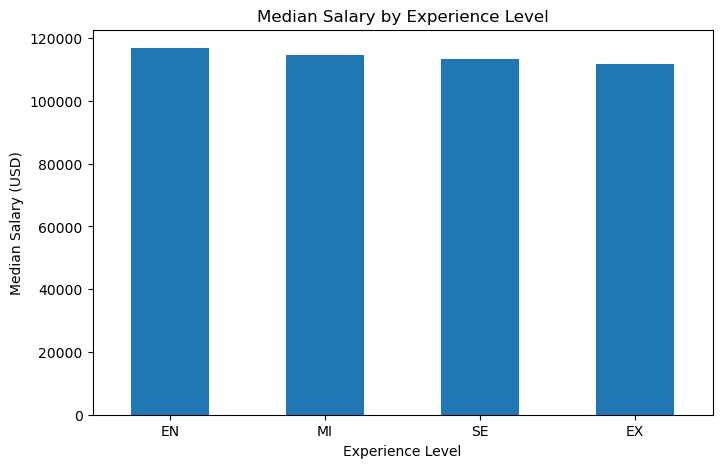

In [9]:
experience_order = ["EN", "MI", "SE", "EX"]

experience_median = (
    df.groupby("experience_level")["salary_in_usd"]
    .median()
    .reindex(experience_order)
)

plt.figure(figsize=(8, 5))

experience_median.plot(kind="bar")

plt.xlabel("Experience Level")
plt.ylabel("Median Salary (USD)")
plt.title("Median Salary by Experience Level")

plt.xticks(rotation=0)

plt.show()

# Salary by Country

In [10]:
country_salary = (
    df.groupby("company_location")["salary_in_usd"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

display(country_salary.head(20))

,count,mean,median
company_location,,,
JP,683,116266.269400,117332.0
US,684,113859.799708,116771.0
MX,713,115175.966339,116613.0
IN,708,113700.105932,114130.5
UK,789,113129.910013,111690.0
DE,726,113979.698347,111611.5
CN,697,112576.922525,109608.0


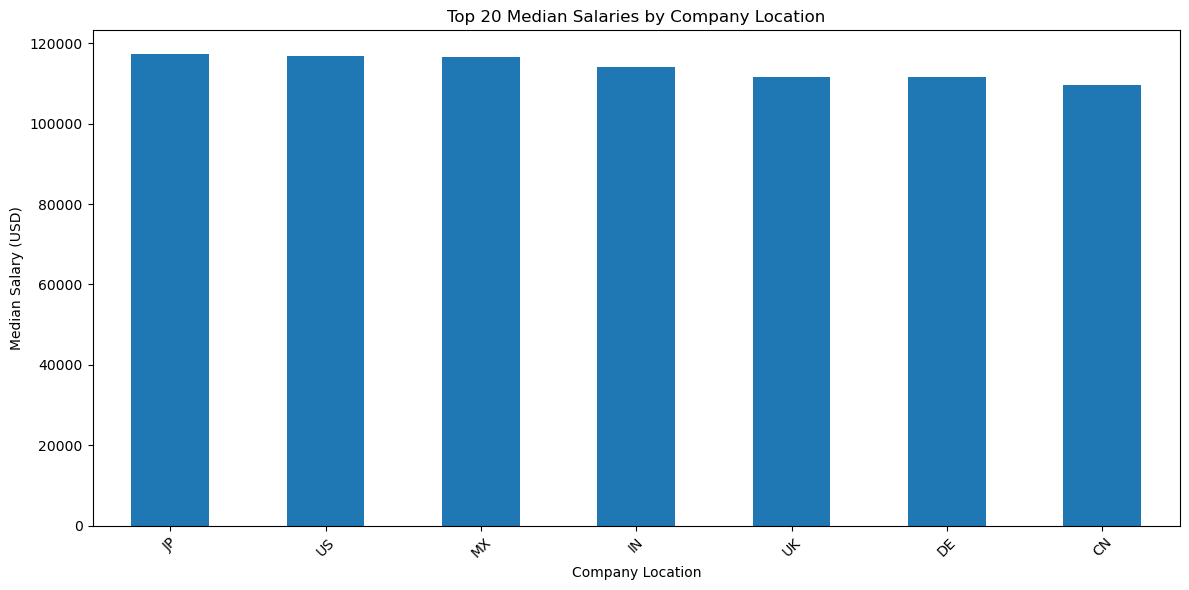

In [11]:
country_counts = df["company_location"].value_counts()

valid_countries = country_counts[
    country_counts >= 20
].index

country_salary_plot = (
    df[df["company_location"].isin(valid_countries)]
    .groupby("company_location")["salary_in_usd"]
    .median()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 6))

country_salary_plot.plot(kind="bar")

plt.xlabel("Company Location")
plt.ylabel("Median Salary (USD)")
plt.title("Top 20 Median Salaries by Company Location")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Salary by Company Size

In [12]:
company_size_salary = (
    df.groupby("company_size")["salary_in_usd"]
    .agg(["count", "mean", "median", "min", "max"])
)

display(company_size_salary)

,count,mean,median,min,max
company_size,,,,,
L,1464,114895.802596,114494.0,30016,199894
M,1517,113401.736981,112119.0,30178,199985
S,1519,113011.419355,113725.0,30056,199808


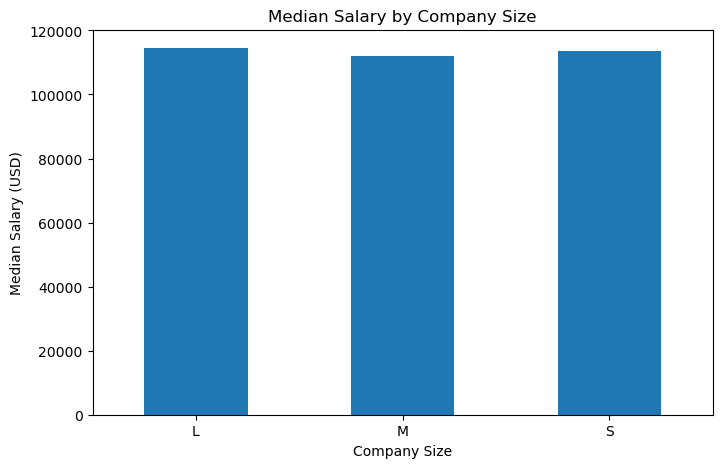

In [13]:
company_size_median = (
    df.groupby("company_size")["salary_in_usd"]
    .median()
)

plt.figure(figsize=(8, 5))

company_size_median.plot(kind="bar")

plt.xlabel("Company Size")
plt.ylabel("Median Salary (USD)")
plt.title("Median Salary by Company Size")

plt.xticks(rotation=0)

plt.show()

# Feature Selection

In [14]:
features = [
    "work_year",
    "job_title",
    "job_category",
    "employee_residence",
    "experience_level",
    "employment_type",
    "work_setting",
    "company_location",
    "company_size"
]

target = "salary_in_usd"

X = df[features].copy()
y = df[target].copy()

print("Features:")
print(features)

print("\nTarget:")
print(target)

Features:
['work_year', 'job_title', 'job_category', 'employee_residence', 'experience_level', 'employment_type', 'work_setting', 'company_location', 'company_size']

Target:
salary_in_usd


In [16]:
numeric_features = [
    "work_year"
]

categorical_features = [
    "job_title",
    "job_category",
    "employee_residence",
    "experience_level",
    "employment_type",
    "work_setting",
    "company_location",
    "company_size"
]

# Preprocessing pipeline

In [17]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

# Train/Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


# First Model: Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression complete!")

Linear Regression complete!


In [23]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("===== LINEAR REGRESSION =====")
print(f"MAE:  ${linear_mae:,.2f}")
print(f"RMSE: ${linear_rmse:,.2f}")
print(f"R²:   {linear_r2:.4f}")

===== LINEAR REGRESSION =====
MAE:  $41,966.31
RMSE: $48,795.56
R²:   -0.0170


# Second Model : Ridge Regression

In [24]:
from sklearn.linear_model import Ridge

In [25]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10))
])

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("===== RIDGE REGRESSION =====")
print(f"MAE:  ${ridge_mae:,.2f}")
print(f"RMSE: ${ridge_rmse:,.2f}")
print(f"R²:   {ridge_r2:.4f}")

===== RIDGE REGRESSION =====
MAE:  $41,958.88
RMSE: $48,786.25
R²:   -0.0166


# Third Model: Random Forest Regression

In [26]:
from sklearn.ensemble import RandomForestRegressor

In [27]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("===== RANDOM FOREST =====")
print(f"MAE:  ${rf_mae:,.2f}")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")

===== RANDOM FOREST =====
MAE:  $43,018.14
RMSE: $50,299.58
R²:   -0.0807


# Fourth Model: Gradient Boosting

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

In [29]:
gradient_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gradient_model.fit(X_train, y_train)

gradient_predictions = gradient_model.predict(X_test)

gradient_mae = mean_absolute_error(
    y_test,
    gradient_predictions
)

gradient_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gradient_predictions
    )
)

gradient_r2 = r2_score(
    y_test,
    gradient_predictions
)

print("===== GRADIENT BOOSTING =====")
print(f"MAE:  ${gradient_mae:,.2f}")
print(f"RMSE: ${gradient_rmse:,.2f}")
print(f"R²:   {gradient_r2:.4f}")

===== GRADIENT BOOSTING =====
MAE:  $42,036.81
RMSE: $49,160.34
R²:   -0.0323


# Compare Models

In [30]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        linear_mae,
        ridge_mae,
        rf_mae,
        gradient_mae
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        gradient_rmse
    ],

    "R2": [
        linear_r2,
        ridge_r2,
        rf_r2,
        gradient_r2
    ]
})

results = results.sort_values(
    "R2",
    ascending=False
)

display(results)

,Model,MAE,RMSE,R2
1,Ridge Regression,41958.877871,48786.251527,-0.016639
0,Linear Regression,41966.310801,48795.557888,-0.017027
3,Gradient Boosting,42036.814239,49160.338415,-0.032290
2,Random Forest,43018.141290,50299.578319,-0.080689


#